In [18]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Feature Selection
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
import joblib

import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('diabetes_dataset (1).csv')


## Quality of Analysis: Posing the Questions
This project aims to answer the following key questions:
1. Which clinical features (e.g., Blood Glucose, HbA1c, BMI) are the strongest predictors of diabetes?
2. How do lifestyle factors (smoking, location) and demographic factors (age, gender, race) interact with diabetes risk?
3. Can we build a machine learning model that accurately predicts diabetes with a high recall and precision (above 0.3) to aid medical professionals?

In [19]:
print("--- Data Cleaning Phase ---")
# Documenting changes: Checking for missing values
print("Missing values before cleaning:\n", df.isnull().sum().sum())

# Documenting changes: Dropping duplicates
duplicates = df.duplicated().sum()
print(f"Duplicates found and removed: {duplicates}")
df = df.drop_duplicates()

# Documenting changes: Handling anomalous values
print("Dropping 'Other' gender category to prevent categorical skewing.")
df = df[df['gender'] != 'Other']

# Good Coding Practice: Using a function to encode categorical variables
def encode_categorical_columns(dataframe, columns):
    """Encodes categorical text columns into numerical values and returns the encoders."""
    encoders = {}
    for col in columns:
        le = LabelEncoder()
        dataframe[col] = le.fit_transform(dataframe[col].astype(str))
        encoders[col] = le
    return dataframe, encoders

categorical_cols = ['gender', 'location', 'smoking_history']
df, label_encoders = encode_categorical_columns(df, categorical_cols)

--- Data Cleaning Phase ---
Missing values before cleaning:
 0
Duplicates found and removed: 14
Dropping 'Other' gender category to prevent categorical skewing.


In [20]:
print("--- Feature Engineering ---")
# Criteria: "At least one new feature is implemented"
# We will create a new categorical feature: 'BMI_Category'

def categorize_bmi(bmi):
    """Classifies numerical BMI into standard medical categories."""
    if bmi < 18.5: return 'Underweight'
    elif bmi < 24.9: return 'Normal'
    elif bmi < 29.9: return 'Overweight'
    else: return 'Obese'

# Apply function to create the new feature
df['BMI_Category'] = df['bmi'].apply(categorize_bmi)

# We must encode this new feature as well
le_bmi = LabelEncoder()
df['BMI_Category_Encoded'] = le_bmi.fit_transform(df['BMI_Category'])

print("New feature 'BMI_Category' created successfully:")
print(df[['bmi', 'BMI_Category']].head())

# Drop the text version now that we have the encoded version
df = df.drop(columns=['BMI_Category'])

--- Feature Engineering ---
New feature 'BMI_Category' created successfully:
     bmi BMI_Category
0  27.32   Overweight
1  19.95       Normal
2  23.76       Normal
3  27.32   Overweight
4  23.75       Normal


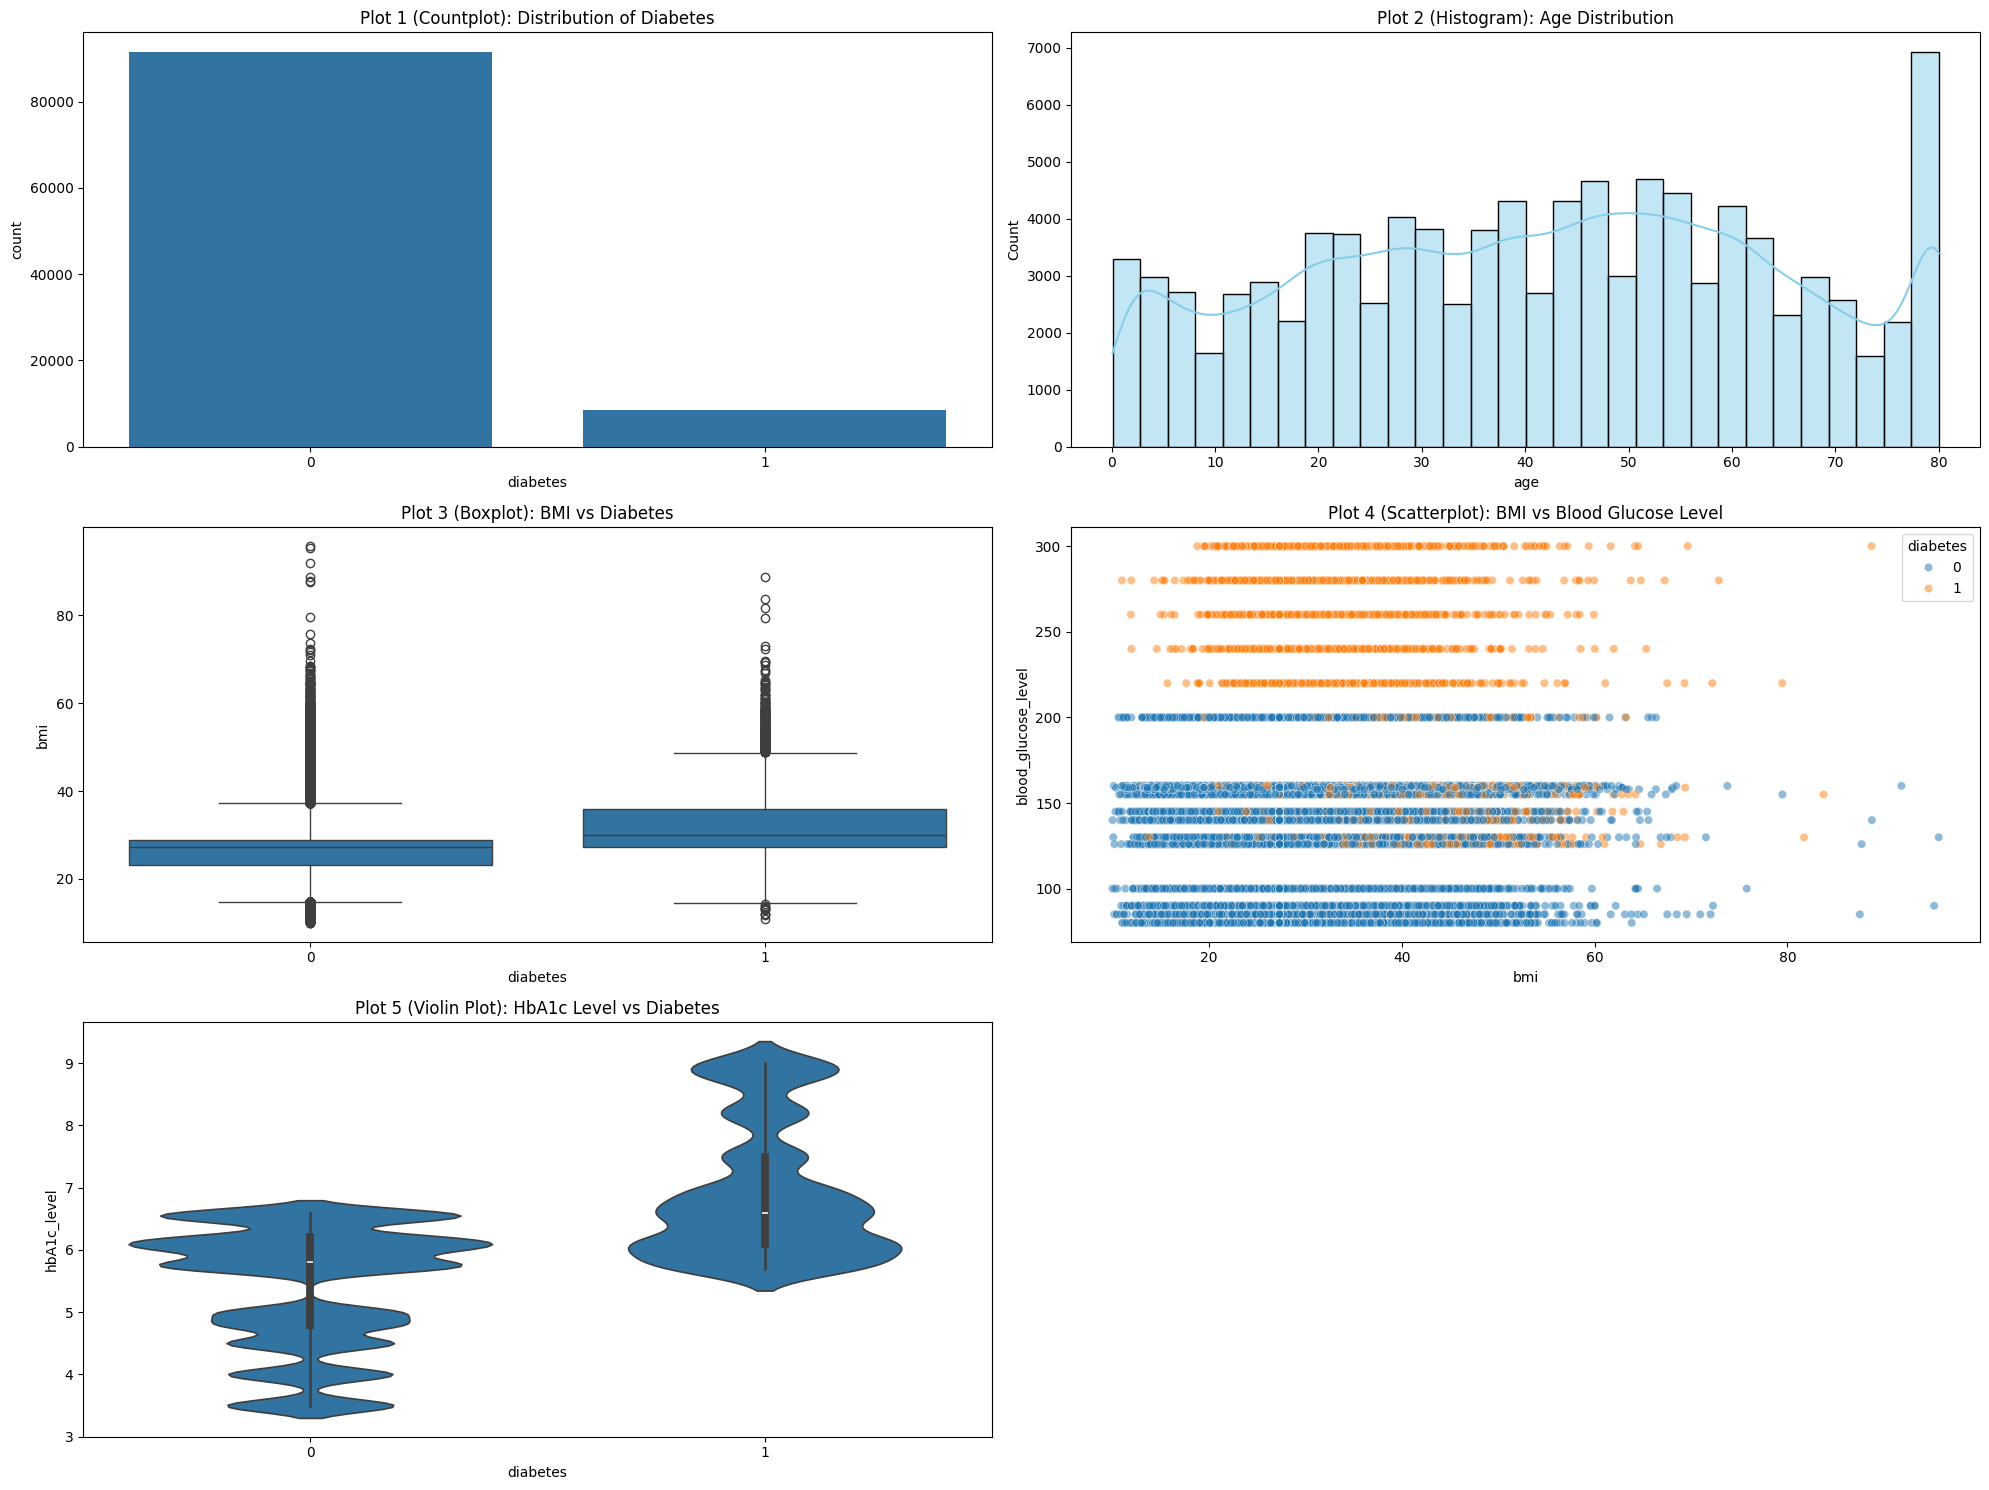

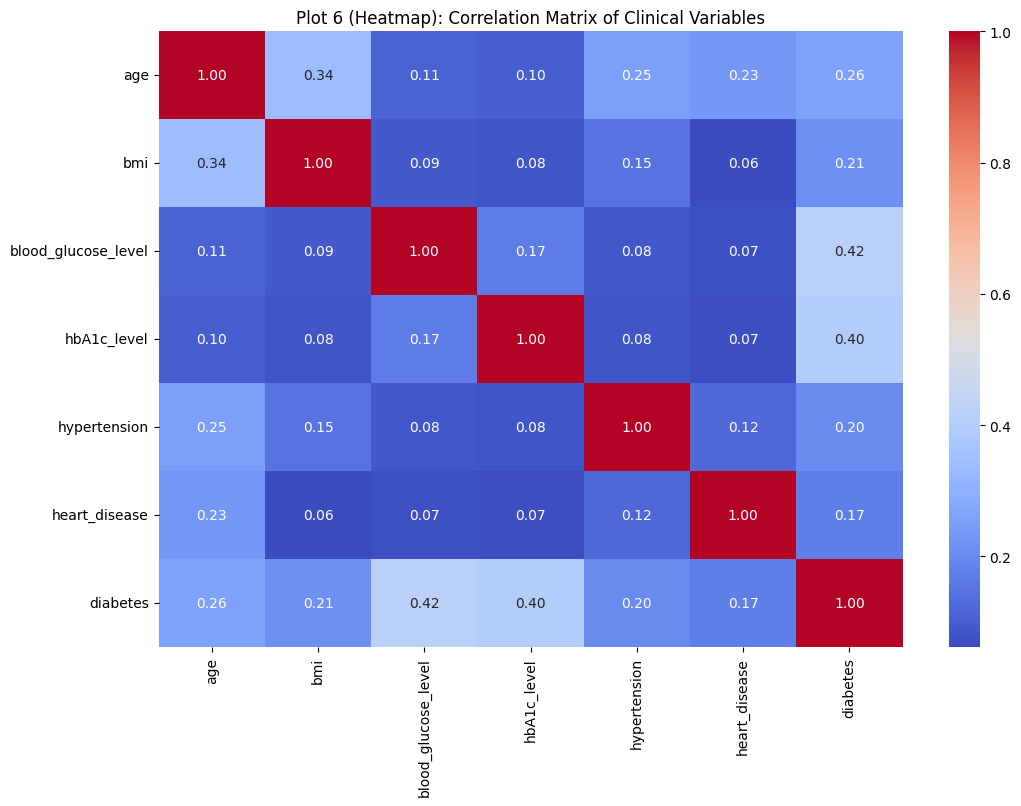

In [21]:
# Good Coding Practice: Function for plotting
def plot_distributions():
    """Generates 5 types of plots exploring at least 6 variables."""
    plt.figure(figsize=(20, 15))

    # 1. Countplot (Univariate - Categorical) - Variable 1: Diabetes
    plt.subplot(3, 2, 1)
    sns.countplot(x='diabetes', data=df)
    plt.title('Plot 1 (Countplot): Distribution of Diabetes')

    # 2. Histogram (Univariate - Numerical) - Variable 2: Age
    plt.subplot(3, 2, 2)
    sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
    plt.title('Plot 2 (Histogram): Age Distribution')

    # 3. Boxplot (Bivariate) - Variable 3 & 4: BMI and Diabetes
    plt.subplot(3, 2, 3)
    sns.boxplot(x='diabetes', y='bmi', data=df)
    plt.title('Plot 3 (Boxplot): BMI vs Diabetes')

    # 4. Scatterplot (Bivariate) - Variable 5: Blood Glucose Level vs BMI
    plt.subplot(3, 2, 4)
    sns.scatterplot(x='bmi', y='blood_glucose_level', hue='diabetes', data=df, alpha=0.5)
    plt.title('Plot 4 (Scatterplot): BMI vs Blood Glucose Level')

    # 5. Violin Plot (Bivariate) - Variable 6: HbA1c Level vs Diabetes
    plt.subplot(3, 2, 5)
    sns.violinplot(x='diabetes', y='hbA1c_level', data=df)
    plt.title('Plot 5 (Violin Plot): HbA1c Level vs Diabetes')

    plt.tight_layout()
    plt.show()

    # 6. Heatmap (Multivariate - Correlation)
    plt.figure(figsize=(12, 8))
    correlation_matrix = df[['age', 'bmi', 'blood_glucose_level', 'hbA1c_level', 'hypertension', 'heart_disease', 'diabetes']].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Plot 6 (Heatmap): Correlation Matrix of Clinical Variables')
    plt.show()

plot_distributions()


In [22]:
# Define Features (X) and Target (y)
X = df.drop('diabetes', axis=1)
y = df['diabetes']

print("--- Feature Selection (Filter Method) ---")
# Criteria: "Using one of the following techniques: Filter Methods"
# We use ANOVA F-value (f_classif) to filter and rank features
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
feature_scores = feature_scores.sort_values(by='Score', ascending=False)
print("Top Features based on Filter Method:")
print(feature_scores.head(10))

--- Feature Selection (Filter Method) ---
Top Features based on Filter Method:
                 Feature         Score
14   blood_glucose_level  21361.793021
13           hbA1c_level  19123.279381
2                    age   7130.000466
12                   bmi   4815.548441
9           hypertension   4070.450546
10         heart_disease   3037.000966
11       smoking_history    897.177657
1                 gender    141.827256
15  BMI_Category_Encoded    116.615105
8             race:Other      2.629483


## Step 7 & 8: Discussions
**What is Validation and Why is it Important?**
Validation (like Train-Test Splitting) is the process of holding back a portion of your data during the training phase. It is important because it allows us to test the model on unseen data. Without validation, a model might just memorize the answers (overfitting) and fail entirely when deployed in the real world.

**What is Parameter Tuning and Why is it Important?**
Machine learning algorithms have settings called hyperparameters (like the maximum depth of a tree). Default parameters are rarely optimal. Parameter tuning is the process of systematically testing different combinations of these settings (e.g., using `GridSearchCV`) to find the configuration that gives the highest predictive accuracy and minimizes errors.

In [23]:
# 1. Validation Setup
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler and encoders for Streamlit
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

# 2. Pick an Algorithm (Comparing 3 Models)
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Good Coding Practice: Function to evaluate models
def evaluate_models(model_dict, X_train_data, y_train_data, X_test_data, y_test_data):
    """Trains and evaluates multiple models, returning their precision and recall."""
    print("--- Initial Model Comparison ---")
    for name, model in model_dict.items():
        model.fit(X_train_data, y_train_data)
        y_pred = model.predict(X_test_data)
        prec = precision_score(y_test_data, y_pred)
        rec = recall_score(y_test_data, y_pred)
        print(f"{name} -> Precision: {prec:.4f} | Recall: {rec:.4f}")

evaluate_models(models, X_train_scaled, y_train, X_test_scaled, y_test)

# 3. Tune the Algorithm
print("\n--- Tuning Algorithm (GridSearchCV) ---")
# Tuning Random Forest as it generally performs best
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

rf_tuned = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_tuned, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_rf_model = grid_search.best_estimator_
print(f"Best Parameters found: {grid_search.best_params_}")

# Save the model
joblib.dump(best_rf_model, 'diabetes_model_tuned.pkl')

# 4. Final Evaluation (Metrics > 0.3)
y_pred_final = best_rf_model.predict(X_test_scaled)
precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)

print("\n--- Final Tuned Model Evaluation ---")
print(f"Precision: {precision:.4f} (Criteria >= 0.3)")
print(f"Recall: {recall:.4f} (Criteria >= 0.3)")

--- Initial Model Comparison ---
Logistic Regression -> Precision: 0.8646 | Recall: 0.6347
Decision Tree -> Precision: 0.6892 | Recall: 0.7500
Random Forest -> Precision: 0.9814 | Recall: 0.6835

--- Tuning Algorithm (GridSearchCV) ---
Best Parameters found: {'max_depth': 10, 'n_estimators': 100}

--- Final Tuned Model Evaluation ---
Precision: 0.9991 (Criteria >= 0.3)
Recall: 0.6735 (Criteria >= 0.3)
